# Capítulo 7 — t-SNE na Prática: do Problema ao Algoritmo

> **Objetivo da aula**

Ao final deste notebook você será capaz de:

- Entender **por que** o t-SNE existe;
- Explicar intuitivamente seu funcionamento;
- Comparar PCA × t-SNE;
- Avaliar reduções de dimensionalidade usando métricas de clusterização;
- Discutir quando utilizar PCA, t-SNE e UMAP.

**Tempo estimado:** 2 horas


# 1. O problema

Imagine que você recebeu um dataset com **500 atributos**.

Como visualizar esses dados?

Como descobrir grupos?

Como explicar o comportamento dos dados para um executivo?

Quando o número de atributos cresce, nossa intuição geométrica desaparece.

É justamente esse problema que técnicas de redução de dimensionalidade procuram resolver.


# 2. Duas filosofias completamente diferentes

## PCA

O PCA pergunta:

> **"Qual projeção preserva a maior quantidade possível de variância?"**

Ele tenta preservar a **estrutura global**.

Imagine tirar uma fotografia aérea de uma cidade.

Você enxerga toda a cidade, mas alguns bairros acabam sobrepostos.

---

## t-SNE

O t-SNE (t-distributed Stochastic Neighbor Embedding) pergunta:

> **"Quem deve continuar próximo de quem?"**

Ele ignora a geometria global.

Seu objetivo é preservar apenas **vizinhanças locais**.

Imagine desenhar um mapa de amizades em vez de um mapa da cidade.


### Analogia

Imagine 1000 pessoas em um auditório de 10 andares sendo transferidas para um único andar. Somente projetar como "sombra" no 1o andar, faltaria espaco => problema da aglomeracao (crowding problem). 

Usar distribuicao t-Student permite "mais espaco" para representar a menor dimensao. Sem a t-Student, todas se amontoariam no mesmo ponto. Com a t-Student, o algoritmo ganha mais liberdade para "espalhar" os pontos, mantendo os grupos intactos mas com espaçamento adequado.

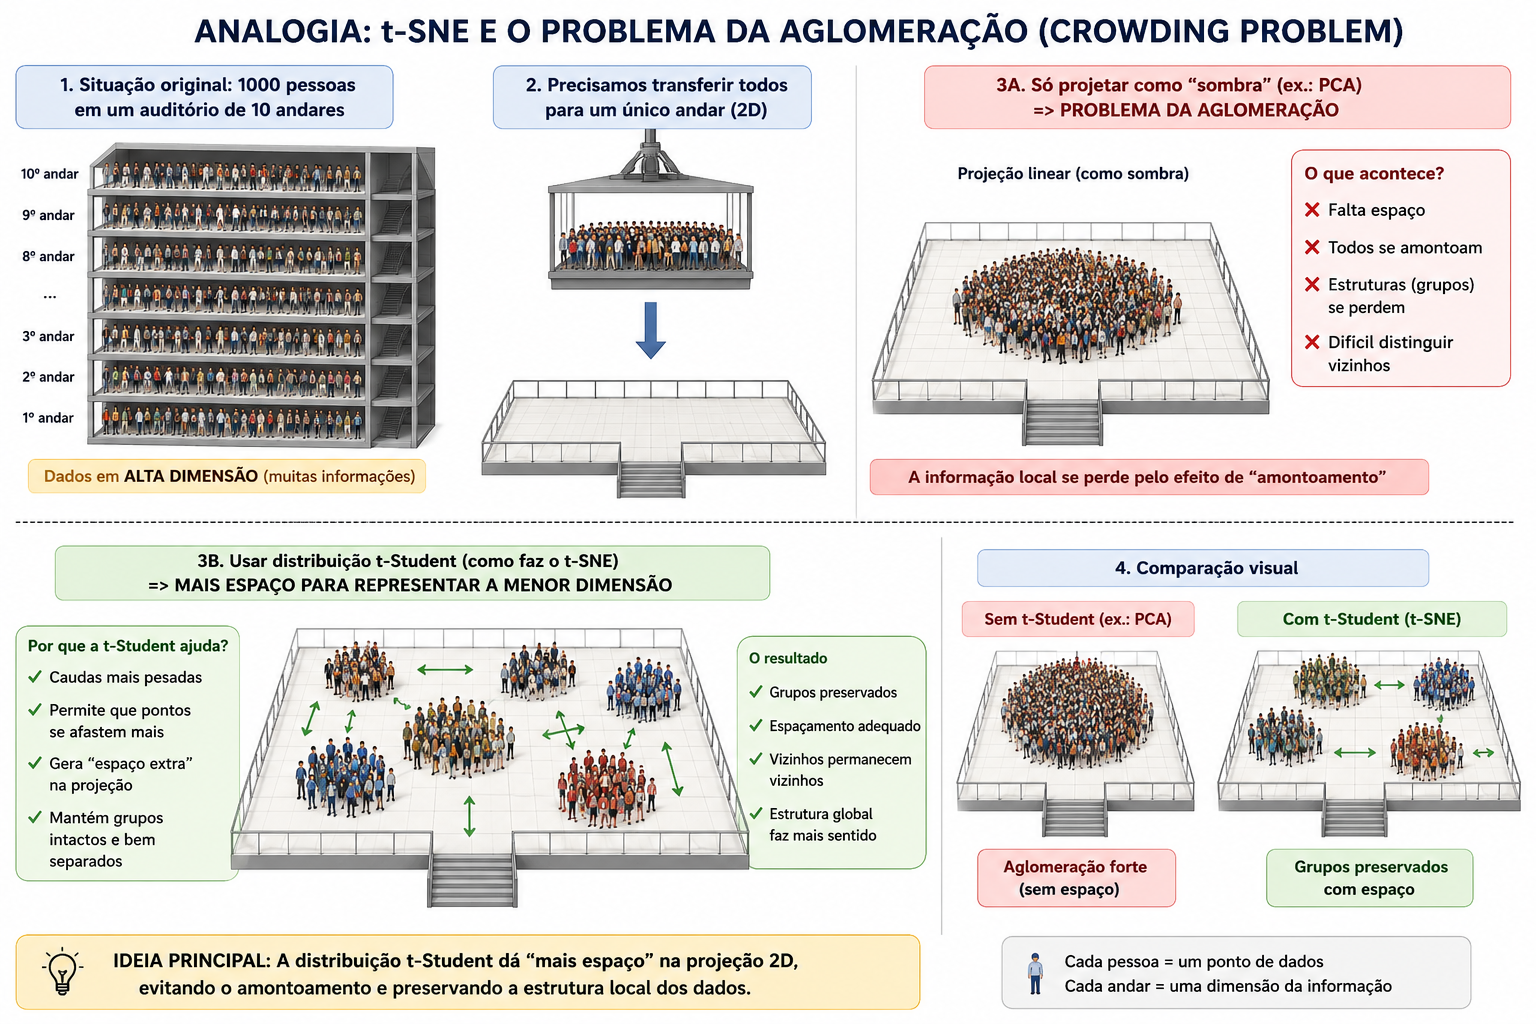

# 3. Construindo a intuição do PCA

Vamos gerar um conjunto de dados sintético e visualizar a direção de maior variância.


Número de amostras: 150
Número de atributos: 4

Atributos:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


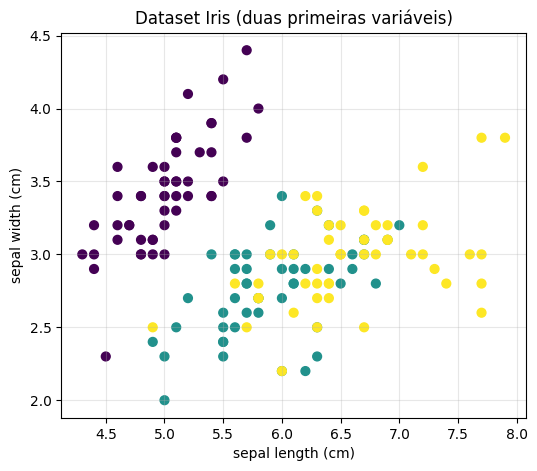


Componentes principais (loadings):
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]

Variância explicada por componente:
[0.72962445 0.22850762]

Variância acumulada:
0.9581320720000165


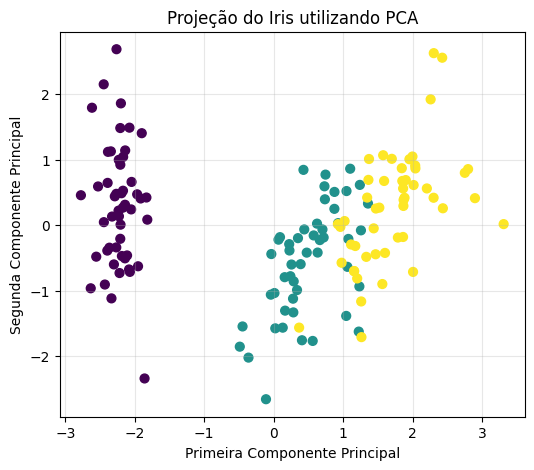

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =====================================================
# 1. Carregando o dataset Iris
# =====================================================

iris = load_iris()

X = iris.data
y = iris.target

print(f"Número de amostras: {X.shape[0]}")
print(f"Número de atributos: {X.shape[1]}")

print("\nAtributos:")
print(iris.feature_names)

# =====================================================
# 2. Visualização dos dados originais
# (apenas as duas primeiras variáveis)
# =====================================================

plt.figure(figsize=(6,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="viridis",
    s=40
)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Dataset Iris (duas primeiras variáveis)")
plt.grid(alpha=0.3)

plt.show()

# =====================================================
# 3. Padronização
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =====================================================
# 4. Aplicando PCA
# =====================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# =====================================================
# 5. Resultados do PCA
# =====================================================

print("\nComponentes principais (loadings):")
print(pca.components_)

print("\nVariância explicada por componente:")
print(pca.explained_variance_ratio_)

print("\nVariância acumulada:")
print(pca.explained_variance_ratio_.sum())

# =====================================================
# 6. Visualização após o PCA
# =====================================================

plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="viridis",
    s=40
)

plt.xlabel("Primeira Componente Principal")
plt.ylabel("Segunda Componente Principal")
plt.title("Projeção do Iris utilizando PCA")
plt.grid(alpha=0.3)

plt.show()

# 5. Aplicação prática t-SNE no Iris

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

iris=load_iris()
X=StandardScaler().fit_transform(iris.data)
y=iris.target

Xpca=PCA(n_components=2,random_state=42).fit_transform(X)

Xtsne=TSNE(
    n_components=2,
    random_state=42
).fit_transform(X)


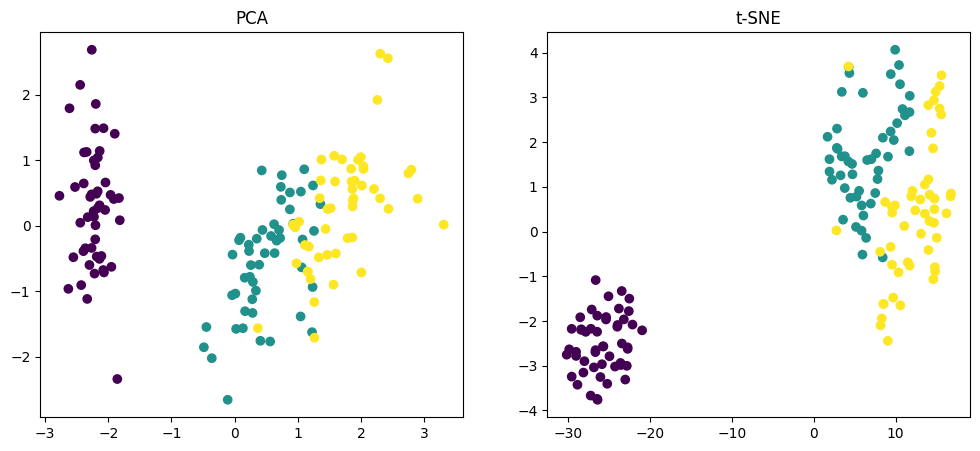

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,5))

ax[0].scatter(Xpca[:,0],Xpca[:,1],c=y,cmap="viridis")
ax[0].set_title("PCA")

ax[1].scatter(Xtsne[:,0],Xtsne[:,1],c=y,cmap="viridis")
ax[1].set_title("t-SNE")

plt.show()


# 6. Pipeline de Clusterização

Agora vamos responder uma pergunta importante:

> **Qual redução de dimensionalidade gera clusters mais bem separados?**


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def avaliar(nome,Xemb):
    km=KMeans(n_clusters=3,n_init=20,random_state=42)
    pred=km.fit_predict(Xemb)
    return {
        "Método":nome,
        "Silhouette":silhouette_score(Xemb,pred),
        "labels":pred
    }

res=[avaliar("PCA",Xpca),avaliar("t-SNE",Xtsne)]

pd.DataFrame([{k:v for k,v in r.items() if k!="labels"} for r in res]).sort_values("Silhouette",ascending=False)


,Método,Silhouette
1,t-SNE,0.640423
0,PCA,0.509168


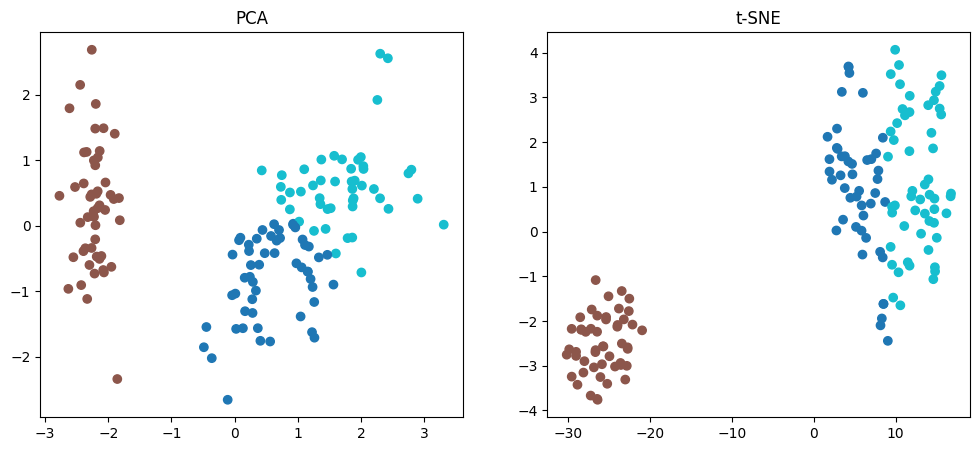

In [5]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
for eixo,r,Xemb in zip(ax,res,[Xpca,Xtsne]):
    eixo.scatter(Xemb[:,0],Xemb[:,1],c=r["labels"],cmap="tab10")
    eixo.set_title(r["Método"])
plt.show()


# 7. Explorando a Perplexity

A *perplexity* controla aproximadamente quantos vizinhos cada ponto considera.

Vamos comparar diferentes valores.


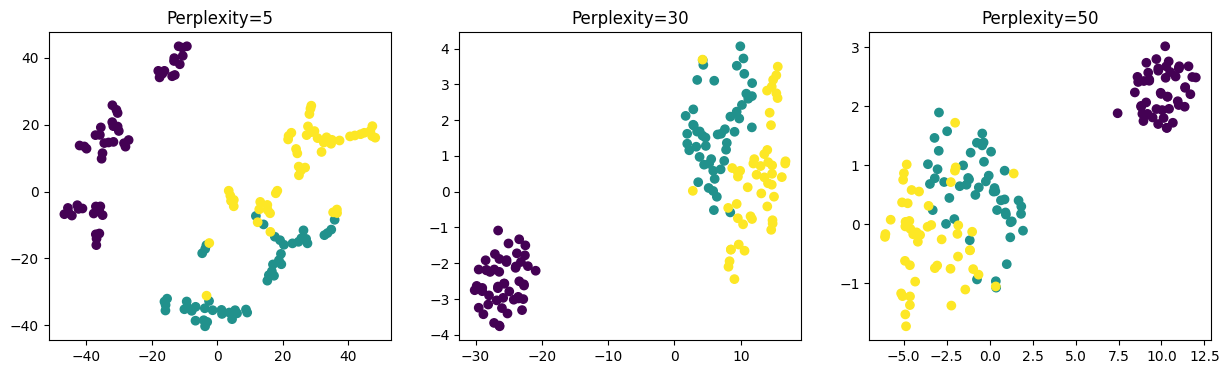

In [6]:
fig,axs=plt.subplots(1,3,figsize=(15,4))

for ax,p in zip(axs,[5,30,50]):
    emb=TSNE(
        n_components=2,
        perplexity=p,
        random_state=42
    ).fit_transform(X)

    ax.scatter(emb[:,0],emb[:,1],c=y,cmap="viridis")
    ax.set_title(f"Perplexity={p}")

plt.show()


# 8. Discussão

## O t-SNE é melhor que o PCA?

Depende da aplicação.

### Para visualização

✅ t-SNE costuma produzir resultados superiores.

### Para pré-processamento de Machine Learning

✅ PCA normalmente é mais indicado.

### Para produção

O PCA permite transformar novos dados de forma consistente.

Já o t-SNE foi desenvolvido principalmente para exploração visual.


## Principais aprendizados

- O PCA preserva **estrutura global**.
- O t-SNE preserva **vizinhanças locais**.
- O t-SNE deve ser interpretado como uma ferramenta de **visualização**, não como uma representação fiel das distâncias globais. Por isso, mais indicado apenas para visualizacao
- Avaliar reduções de dimensionalidade exige combinar inspeção visual, métricas e conhecimento do problema.
